# EIP-7904 Call Graph Analysis — How Changes Propagate

Smart contracts rarely act alone. A single transaction can trigger a cascade of internal calls —
contract A calls B, which calls C, which calls D. When EIP-7904 reprices opcodes, the extra gas
cost doesn't just affect the contract executing the opcode. It ripples outward through the entire
call graph, squeezing gas budgets at every level.

This notebook traces those ripples. We ask:

- **Where in the call graph do failures occur?** At the root? Deep in the tree?
- **Which contract-to-contract edges break most often?** What are the recurring motifs?
- **Which contracts act as chokepoints?** Intermediaries that sit between callers and failing callees.
- **Where does the first divergence happen?** The point where baseline and repriced execution paths split.

**Data sources:** DuckDB (`hot_7904`, `status_change_call_frames`) and pre-computed CSVs from the
`artifacts/tables/` directory. See `01_impact_overview.ipynb` for headline numbers and
`02_status_changes.ipynb` for the status-change deep dive.

## 1. Setup

In [1]:
from helpers import *
import numpy as np
from plotly.subplots import make_subplots

print(f"DuckDB: {DUCKDB_PATH}")
print(f"Tables: {TABLES_DIR}")
print(f"Figures: {FIGURES_DIR}")

DuckDB: /Users/carl/projects/advanced-repricing-analysis/duckdb/eip7904.duckdb
Tables: /Users/carl/projects/advanced-repricing-analysis/artifacts/tables
Figures: /Users/carl/projects/advanced-repricing-analysis/artifacts/figures


## 2. Call Tree Changes Overview

Before diving into failure paths, let's understand the big picture. Of the 5.59M divergent
transactions in `hot_7904`, how many have their call tree changed? And of those, how many
also flip transaction status (success to failure or vice versa)?

A call tree change without a status change means the transaction still succeeds, but the
internal call pattern is different — perhaps a sub-call that used to succeed now fails silently,
or gas forwarding changes cause different code paths to execute.

In [2]:
# Venn-style breakdown of divergence types
overview = query("""
    SELECT
        count(*) AS total_divergent,
        sum(CASE WHEN call_tree_changed THEN 1 ELSE 0 END) AS call_tree_changed,
        sum(CASE WHEN status_changed THEN 1 ELSE 0 END) AS status_changed,
        sum(CASE WHEN event_logs_changed THEN 1 ELSE 0 END) AS event_logs_changed,
        sum(CASE WHEN call_tree_changed AND status_changed THEN 1 ELSE 0 END) AS both_tree_and_status,
        sum(CASE WHEN call_tree_changed AND NOT status_changed THEN 1 ELSE 0 END) AS tree_only,
        sum(CASE WHEN status_changed AND NOT call_tree_changed THEN 1 ELSE 0 END) AS status_only,
        sum(CASE WHEN call_tree_changed AND event_logs_changed THEN 1 ELSE 0 END) AS tree_and_events,
        sum(CASE WHEN call_tree_changed AND status_changed AND event_logs_changed THEN 1 ELSE 0 END) AS all_three
    FROM hot_7904
""")

total = int(overview['total_divergent'].iloc[0])
ct_changed = int(overview['call_tree_changed'].iloc[0])
st_changed = int(overview['status_changed'].iloc[0])
ev_changed = int(overview['event_logs_changed'].iloc[0])
both = int(overview['both_tree_and_status'].iloc[0])
tree_only = int(overview['tree_only'].iloc[0])
status_only = int(overview['status_only'].iloc[0])

print(f"Total divergent transactions: {fmt_count(total)}")
print(f"\nCall tree changed:    {fmt_count(ct_changed)} ({ct_changed/total*100:.1f}%)")
print(f"Status changed:       {fmt_count(st_changed)} ({st_changed/total*100:.1f}%)")
print(f"Event logs changed:   {fmt_count(ev_changed)} ({ev_changed/total*100:.1f}%)")
print(f"\nBoth tree + status:   {fmt_count(both)} ({both/total*100:.2f}%)")
print(f"Tree only (no status flip): {fmt_count(tree_only)} ({tree_only/total*100:.1f}%)")
print(f"Status only (no tree change): {fmt_count(status_only)} ({status_only/total*100:.2f}%)")

Total divergent transactions: 5.59M

Call tree changed:    5.59M (100.0%)
Status changed:       270.9K (4.8%)
Event logs changed:   150.8K (2.7%)

Both tree + status:   270.9K (4.84%)
Tree only (no status flip): 5.32M (95.2%)
Status only (no tree change): 0 (0.00%)


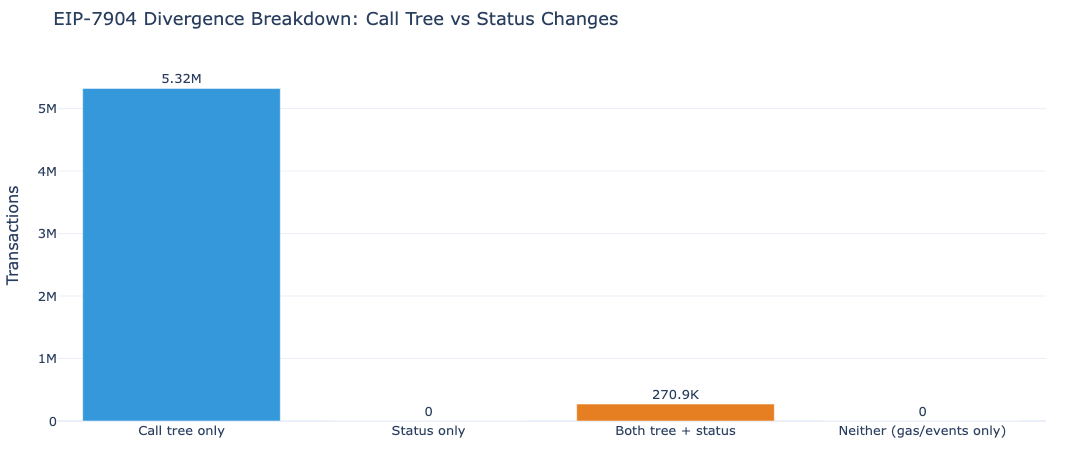


Key insight: 5.32M transactions have call tree changes WITHOUT status flips.
These represent silent behavioral changes — the tx still succeeds but internal calls differ.


In [3]:
# Venn-diagram-style bar chart
categories = [
    'Call tree only',
    'Status only',
    'Both tree + status',
    'Neither (gas/events only)',
]
neither = total - ct_changed - status_only
values = [tree_only, status_only, both, neither]
colors = [COLORS['call_tree'], COLORS['status'], COLORS['changed'], COLORS['neutral']]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=categories, y=values,
    marker_color=colors,
    text=[fmt_count(v) for v in values],
    textposition='outside',
))
fig.update_layout(**plotly_layout(
    title_text='EIP-7904 Divergence Breakdown: Call Tree vs Status Changes',
    yaxis_title='Transactions',
    height=450, width=800,
))
fig.show()

print(f"\nKey insight: {fmt_count(tree_only)} transactions have call tree changes WITHOUT status flips.")
print(f"These represent silent behavioral changes — the tx still succeeds but internal calls differ.")

## 3. Failure Path Analysis

When a transaction's status flips from success to failure under EIP-7904, where in the call graph
does the failure actually occur? The `tx_failure_paths` table traces each broken transaction from
the root contract through intermediaries to the exact point of failure.

Two key metrics:
- **failure_depth**: How deep in the call tree the failure occurs (1 = direct call, 2+ = nested)
- **path_length**: Total length of the call path from entry to failure point

Deep failures are harder to fix — they often involve hardcoded gas stipends in intermediate contracts.

In [4]:
# Load a sample of failure paths (171MB full file)
fp = pd.read_csv(TABLES_DIR / 'tx_failure_paths.csv', nrows=50000)
print(f"Failure paths sample: {fmt_count(len(fp))} rows")
print(f"Unique transactions: {fmt_count(fp['divergence_id'].nunique())}")
print(f"Unique failing callees: {fp['failing_callee'].nunique()}")
print(f"Unique root callees: {fp['root_callee'].nunique()}")
fp.head(3)

Failure paths sample: 50.0K rows
Unique transactions: 50.0K
Unique failing callees: 1707
Unique root callees: 1707


,divergence_id,block_number,tx_index,tx_hash,recipient,recipient_project,gas_delta,root_callee,root_project,failing_caller,...,path_projects,path_length,pair_motif,triple_motif,first_diff_caller,first_diff_caller_project,first_diff_callee,first_diff_callee_project,first_diff_depth,first_diff_reason
0,250617,24649429,128,0x5076651445053417e8aa36b8018a85b63e158a253861...,0xdac17f958d2ee523a2206206994597c13d831ec7,Tether USDT,4916,0xdac17f958d2ee523a2206206994597c13d831ec7,Tether USDT,0x0c334f38108a46e9772837ce72a67f6a6b8ddf70,...,"[""Tether USDT""]",1,Tether USDT,Tether USDT,0x0c334f38108a46e9772837ce72a67f6a6b8ddf70,0x0c334f38108a46e9772837ce72a67f6a6b8ddf70,0xdac17f958d2ee523a2206206994597c13d831ec7,Tether USDT,0,"success_flip,gas_delta"
1,251509,24649432,428,0xb742fd0da36a7c7f1fe30f4666a0ea103ab750e6e8f9...,0xdac17f958d2ee523a2206206994597c13d831ec7,Tether USDT,4916,0xdac17f958d2ee523a2206206994597c13d831ec7,Tether USDT,0x476a9da9becf33e99d062ef77447fff9d2065c85,...,"[""Tether USDT""]",1,Tether USDT,Tether USDT,0x476a9da9becf33e99d062ef77447fff9d2065c85,0x476a9da9becf33e99d062ef77447fff9d2065c85,0xdac17f958d2ee523a2206206994597c13d831ec7,Tether USDT,0,"success_flip,gas_delta"
2,350924,24649929,242,0xb30f162a54074fe576022f03dc44a57066526291872f...,0xadc87ecf8ff4009982893f17704394a15bbc25c4,0xadc87ecf8ff4009982893f17704394a15bbc25c4,-476,0xadc87ecf8ff4009982893f17704394a15bbc25c4,0xadc87ecf8ff4009982893f17704394a15bbc25c4,0x2960c7e910f198c3b95016508545a83422167046,...,"[""0xadc87ecf8ff4009982893f17704394a15bbc25c4""]",1,0xadc87ecf8ff4009982893f17704394a15bbc25c4,0xadc87ecf8ff4009982893f17704394a15bbc25c4,0x2960c7e910f198c3b95016508545a83422167046,0x2960c7e910f198c3b95016508545a83422167046,0xadc87ecf8ff4009982893f17704394a15bbc25c4,0xadc87ecf8ff4009982893f17704394a15bbc25c4,0,"success_flip,gas_delta"


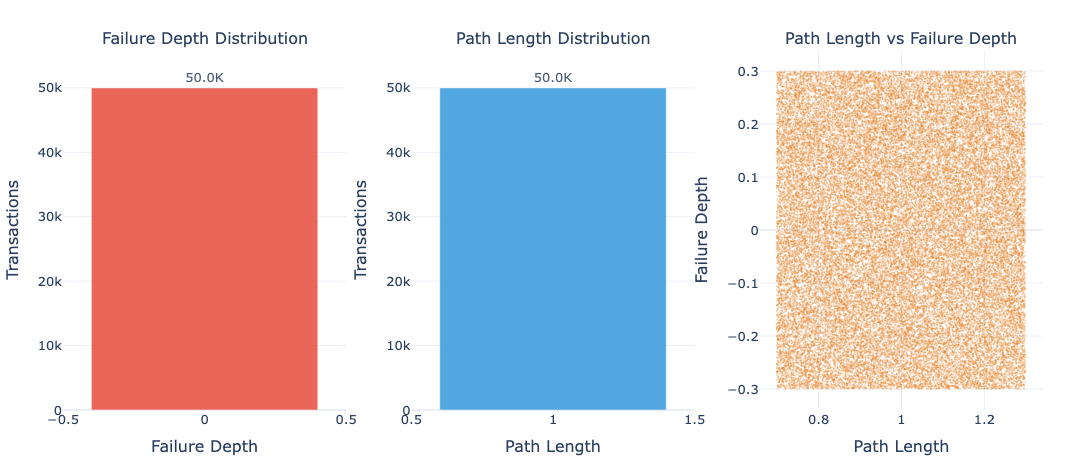

Median failure depth: 0, Median path length: 1
Failures at depth >= 3: 0.0% — these involve multiple intermediary contracts


In [5]:
# Distribution of failure_depth and path_length
fig = make_subplots(rows=1, cols=3, subplot_titles=[
    'Failure Depth Distribution',
    'Path Length Distribution',
    'Path Length vs Failure Depth',
])

# 1. Failure depth
depth_counts = fp['failure_depth'].value_counts().sort_index()
fig.add_trace(go.Bar(
    x=depth_counts.index.tolist(), y=depth_counts.values,
    marker_color=COLORS['status'], opacity=0.85,
    text=[fmt_count(v) for v in depth_counts.values],
    textposition='outside', showlegend=False,
), row=1, col=1)
fig.update_xaxes(title_text='Failure Depth', row=1, col=1)
fig.update_yaxes(title_text='Transactions', row=1, col=1)

# 2. Path length
path_counts = fp['path_length'].value_counts().sort_index()
fig.add_trace(go.Bar(
    x=path_counts.index.tolist(), y=path_counts.values,
    marker_color=COLORS['call_tree'], opacity=0.85,
    text=[fmt_count(v) for v in path_counts.values],
    textposition='outside', showlegend=False,
), row=1, col=2)
fig.update_xaxes(title_text='Path Length', row=1, col=2)
fig.update_yaxes(title_text='Transactions', row=1, col=2)

# 3. Scatter: path length vs failure depth
jittered = fp[['path_length', 'failure_depth']].copy()
jittered['path_jitter'] = jittered['path_length'] + np.random.uniform(-0.3, 0.3, len(jittered))
jittered['depth_jitter'] = jittered['failure_depth'] + np.random.uniform(-0.3, 0.3, len(jittered))
fig.add_trace(go.Scattergl(
    x=jittered['path_jitter'], y=jittered['depth_jitter'],
    mode='markers', marker=dict(size=2, color=COLORS['changed'], opacity=0.3),
    showlegend=False,
), row=1, col=3)
fig.update_xaxes(title_text='Path Length', row=1, col=3)
fig.update_yaxes(title_text='Failure Depth', row=1, col=3)

fig.update_layout(**plotly_layout(
    height=450, width=1200,
))
fig.show()

med_depth = fp['failure_depth'].median()
med_path = fp['path_length'].median()
deep_frac = (fp['failure_depth'] >= 3).sum() / len(fp) * 100
print(f"Median failure depth: {med_depth:.0f}, Median path length: {med_path:.0f}")
print(f"Failures at depth >= 3: {deep_frac:.1f}% — these involve multiple intermediary contracts")

## 4. Top Failure Motifs

A failure motif captures the recurring pattern of *which project calls which project* at the
point of failure. The `pair_motif` column encodes this as `caller_project -> callee_project`.

These motifs reveal the structural vulnerabilities in Ethereum's contract ecosystem — the
specific cross-contract interactions that can't absorb the gas cost increase.

In [6]:
motifs = read_table('failure_motifs.csv')
print(f"Failure motifs: {fmt_count(len(motifs))} unique patterns")
print(f"Total status failures across all motifs: {fmt_count(motifs['status_failures'].sum())}")
motifs.head(5)

Failure motifs: 4,921 unique patterns
Total status failures across all motifs: 270.4K


,pair_motif,triple_motif,status_failures,avg_gas_provided,avg_gas_used
0,Tether USDT,Tether USDT,198139,24437.319967,0.0
1,Uniswap V2 Router,Uniswap V2 Router,5648,142043.000000,0.0
2,Safe,Safe,5402,756502.243984,0.0
3,Circle USDC,Circle USDC,3722,29848.809780,0.0
4,Uniswap,Uniswap,3300,665416.150303,0.0


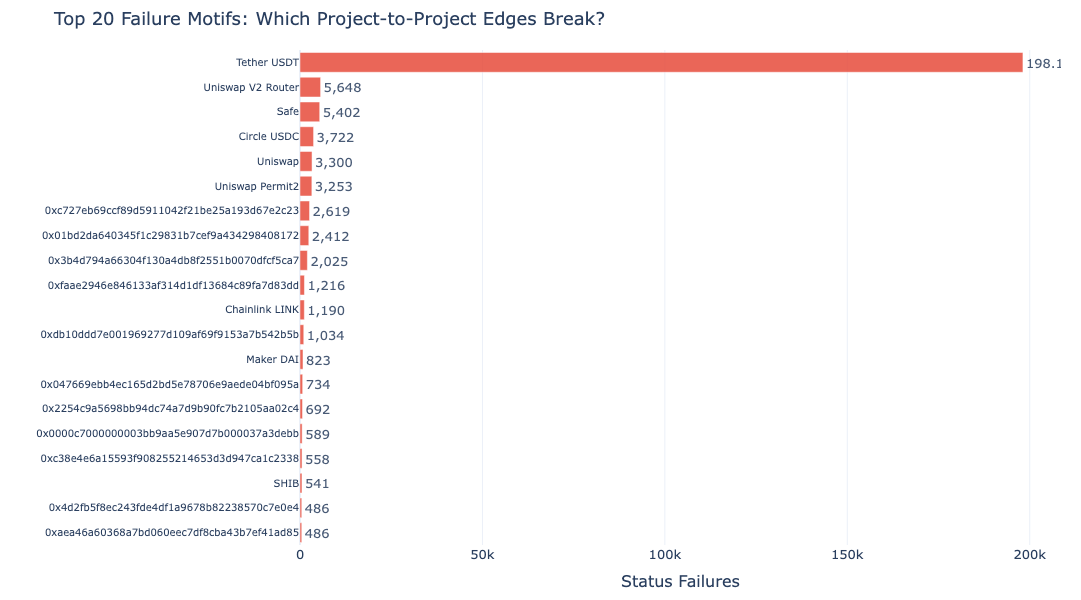


Dominant motif: Tether USDT with 198.1K failures
Average gas provided: 24.4K, used: 0


In [7]:
# Top 20 pair motifs by status_failures
top_pairs = motifs.nlargest(20, 'status_failures').copy()
top_pairs = top_pairs.sort_values('status_failures', ascending=True)

fig = go.Figure()
fig.add_trace(go.Bar(
    y=top_pairs['pair_motif'].tolist(),
    x=top_pairs['status_failures'].tolist(),
    orientation='h',
    marker_color=COLORS['status'],
    opacity=0.85,
    text=[fmt_count(v) for v in top_pairs['status_failures']],
    textposition='outside',
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Status failures: %{x:,}<br>'
        'Avg gas provided: %{customdata[0]:,.0f}<br>'
        'Avg gas used: %{customdata[1]:,.0f}<extra></extra>'
    ),
    customdata=top_pairs[['avg_gas_provided', 'avg_gas_used']].values,
))
fig.update_layout(**plotly_layout(
    title_text='Top 20 Failure Motifs: Which Project-to-Project Edges Break?',
    xaxis_title='Status Failures',
    height=600, width=900,
    margin=dict(l=300, r=20, t=50, b=40),
))
fig.update_yaxes(tickfont=dict(size=10))
fig.show()

top1 = top_pairs.iloc[-1]
print(f"\nDominant motif: {top1['pair_motif']} with {fmt_count(top1['status_failures'])} failures")
print(f"Average gas provided: {fmt_gas(top1['avg_gas_provided'])}, used: {fmt_gas(top1['avg_gas_used'])}")

## 5. Failure Flow Sankey

The Sankey diagram below traces how failures propagate through the call graph. Each flow represents
a path from the **root project** (the contract the user's transaction originally called) through
the **failing caller** (the intermediary that forwarded insufficient gas) to the **failing callee**
(the contract where execution actually runs out of gas).

Wide flows indicate high-traffic failure paths — the most common ways EIP-7904 breaks transactions.

Failure Sankey edges: 5,000
Total status failures in sample: 65.8K


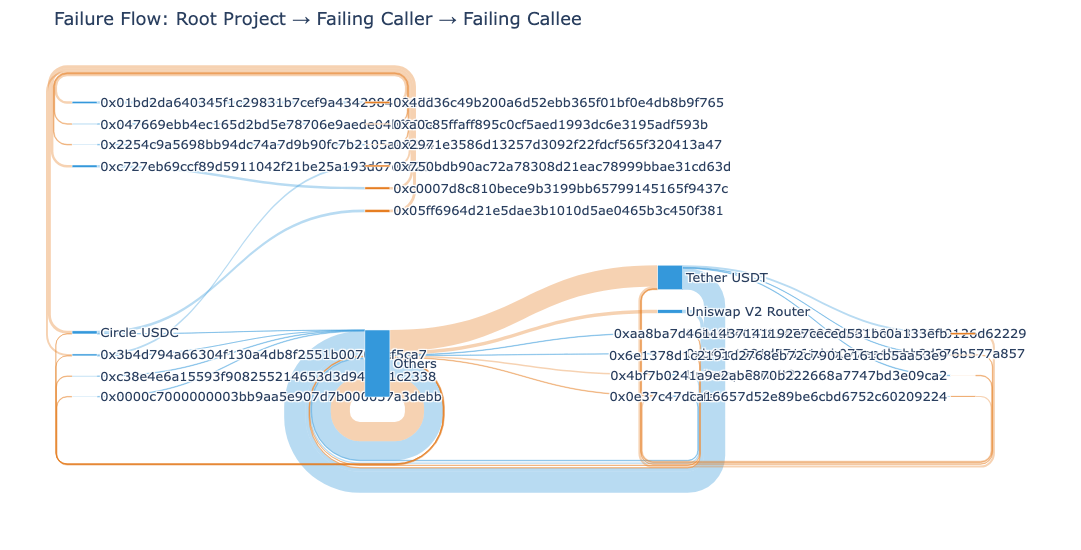

In [8]:
# Load failure path Sankey edges
fp_sankey = pd.read_csv(TABLES_DIR / 'failure_path_sankey_edges.csv', nrows=5000)
print(f"Failure Sankey edges: {fmt_count(len(fp_sankey))}")
print(f"Total status failures in sample: {fmt_count(fp_sankey['status_failures'].sum())}")

fig = plot_sankey(
    fp_sankey,
    columns=['root_project', 'failing_caller_project', 'failing_callee_project'],
    title='Failure Flow: Root Project → Failing Caller → Failing Callee',
    value_col='status_failures',
    min_flow=10,
    top_n=12,
    width=950, height=550,
)
fig.show()

The Sankey reveals the dominant failure corridors. Follow the thickest flows to see the most
impactful propagation paths — these are the contract interactions most likely to cause user-visible
breakage after EIP-7904 activation.

## 6. Intermediary Analysis — The Chokepoints

Not all contracts are equally important in the failure graph. Some sit at critical junctions,
mediating between many callers and many failing callees. These **chokepoints** are where gas
gets squeezed — the intermediary forwards a fixed or calculated gas stipend to its callees,
and that stipend is no longer sufficient under EIP-7904.

The `mediation_score` captures how central a contract is in the failure graph: higher scores
mean the contract mediates more distinct caller-callee failure relationships.

Intermediary contracts: 5,000
Total status-changed txs mediated: 68.5K


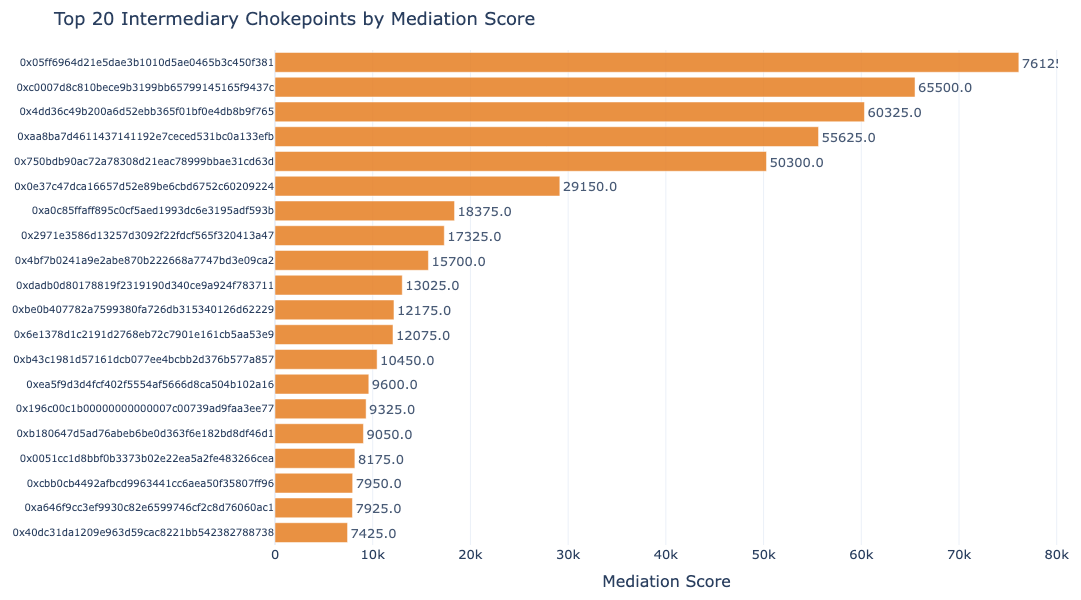


Top chokepoint: 0x05ff6964d21e5dae3b1010d5ae0465b3c450f381
  Mediation score: 76125.0
  Status-changed txs: 3,044
  Distinct failing callees: 1
  Distinct root projects: 1


In [9]:
# Load intermediary centrality
centrality = pd.read_csv(TABLES_DIR / 'intermediary_centrality.csv', nrows=5000)
print(f"Intermediary contracts: {fmt_count(len(centrality))}")
print(f"Total status-changed txs mediated: {fmt_count(centrality['status_changed_txs'].sum())}")

top_central = centrality.nlargest(20, 'mediation_score').copy()
top_central['label'] = top_central['project'].fillna(top_central['address'].str[:12] + '...')
top_central = top_central.sort_values('mediation_score', ascending=True)

fig = go.Figure()
fig.add_trace(go.Bar(
    y=top_central['label'].tolist(),
    x=top_central['mediation_score'].tolist(),
    orientation='h',
    marker_color=COLORS['changed'],
    opacity=0.85,
    text=[f"{v:.1f}" for v in top_central['mediation_score']],
    textposition='outside',
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Mediation score: %{x:.1f}<br>'
        'Status-changed txs: %{customdata[0]:,}<br>'
        'Distinct failing callees: %{customdata[1]}<br>'
        'Distinct root projects: %{customdata[2]}<extra></extra>'
    ),
    customdata=top_central[['status_changed_txs', 'distinct_failing_callees', 'distinct_root_projects']].values,
))
fig.update_layout(**plotly_layout(
    title_text='Top 20 Intermediary Chokepoints by Mediation Score',
    xaxis_title='Mediation Score',
    height=600, width=900,
    margin=dict(l=250, r=20, t=50, b=40),
))
fig.update_yaxes(tickfont=dict(size=10))
fig.show()

top1 = top_central.iloc[-1]
print(f"\nTop chokepoint: {top1['label']}")
print(f"  Mediation score: {top1['mediation_score']:.1f}")
print(f"  Status-changed txs: {fmt_count(top1['status_changed_txs'])}")
print(f"  Distinct failing callees: {top1['distinct_failing_callees']}")
print(f"  Distinct root projects: {top1['distinct_root_projects']}")

These chokepoints are the contracts that the Ethereum community would need to coordinate around.
If a top-scoring intermediary is upgradeable, a gas stipend fix could resolve failures for many
downstream callees at once. If it's immutable, those failure paths are permanently broken.

## 7. Breakpoint Analysis — Where the First Change Happens

A *breakpoint* is a contract where the **first behavioral change** occurs in a non-root call edge.
While chokepoints (above) measure who mediates failure, breakpoints measure who *initiates* the
divergence. These are the contracts where the baseline and repriced execution paths first split.

The `breakpoint_score` weighs how many distinct root projects and downstream projects are affected
by each breakpoint — higher scores indicate contracts whose behavioral change has the widest blast radius.

Breakpoint contracts: 9,631
Total breakpoint txs: 57.3K


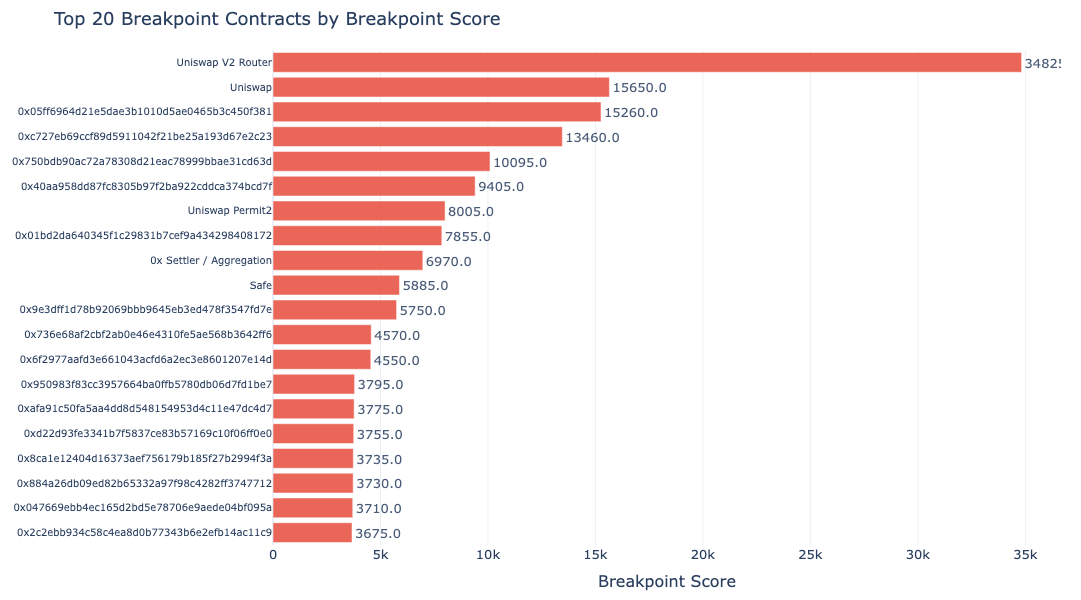


Top breakpoint: Uniswap V2 Router
  Breakpoint score: 34825.0
  Breakpoint txs: 5,641
  Affects 6 root projects and 325 downstream projects


In [10]:
breakpoints = read_table('intermediary_breakpoints.csv')
print(f"Breakpoint contracts: {fmt_count(len(breakpoints))}")
print(f"Total breakpoint txs: {fmt_count(breakpoints['breakpoint_txs'].sum())}")

top_bp = breakpoints.nlargest(20, 'breakpoint_score').copy()
top_bp['label'] = top_bp['project'].fillna(top_bp['address'].str[:12] + '...')
top_bp = top_bp.sort_values('breakpoint_score', ascending=True)

fig = go.Figure()
fig.add_trace(go.Bar(
    y=top_bp['label'].tolist(),
    x=top_bp['breakpoint_score'].tolist(),
    orientation='h',
    marker_color=COLORS['7904'],
    opacity=0.85,
    text=[f"{v:.1f}" for v in top_bp['breakpoint_score']],
    textposition='outside',
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Breakpoint score: %{x:.1f}<br>'
        'Breakpoint txs: %{customdata[0]:,}<br>'
        'Distinct root projects: %{customdata[1]}<br>'
        'Distinct downstream projects: %{customdata[2]}<br>'
        'Success flip txs: %{customdata[3]:,}<extra></extra>'
    ),
    customdata=top_bp[['breakpoint_txs', 'distinct_root_projects', 'distinct_downstream_projects', 'success_flip_txs']].values,
))
fig.update_layout(**plotly_layout(
    title_text='Top 20 Breakpoint Contracts by Breakpoint Score',
    xaxis_title='Breakpoint Score',
    height=600, width=900,
    margin=dict(l=250, r=20, t=50, b=40),
))
fig.update_yaxes(tickfont=dict(size=10))
fig.show()

top1 = top_bp.iloc[-1]
print(f"\nTop breakpoint: {top1['label']}")
print(f"  Breakpoint score: {top1['breakpoint_score']:.1f}")
print(f"  Breakpoint txs: {fmt_count(top1['breakpoint_txs'])}")
print(f"  Affects {top1['distinct_root_projects']} root projects and {top1['distinct_downstream_projects']} downstream projects")

## 8. Changed Edge Motifs

Beyond outright failures, EIP-7904 changes the behavior of many cross-contract call edges.
A *changed edge* is a caller-to-callee pair whose execution differs between baseline and repriced
schedules — the call might use different gas, take a different code path, or flip success/failure.

These motifs show which project-to-project interactions are most sensitive to gas cost changes,
colored by the depth at which they occur in the call tree.

Changed edge motifs: 10.0K
Total changed edges: 1.66M
Total distinct txs: 520.5K


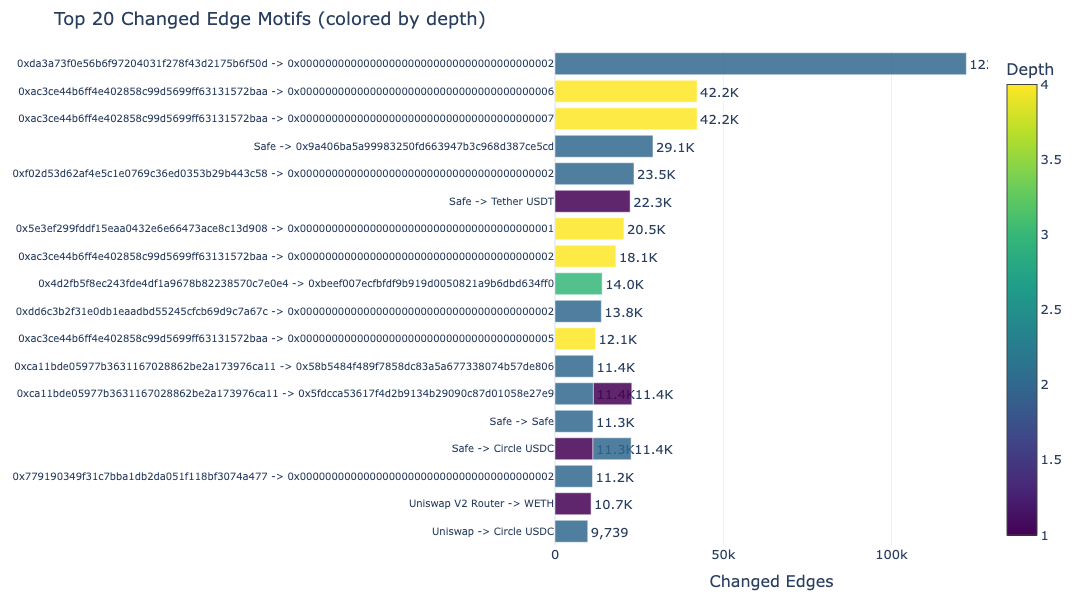


Shallow changes (depth <= 2): 780.2K (47.0%)
Deep changes (depth > 2): 880.9K (53.0%)


In [11]:
# Load changed edge motifs
edge_motifs = pd.read_csv(TABLES_DIR / 'changed_edge_motifs.csv', nrows=10000)
print(f"Changed edge motifs: {fmt_count(len(edge_motifs))}")
print(f"Total changed edges: {fmt_count(edge_motifs['changed_edges'].sum())}")
print(f"Total distinct txs: {fmt_count(edge_motifs['distinct_txs'].sum())}")

# Top 20 by changed_edges
top_edges = edge_motifs.nlargest(20, 'changed_edges').copy()
top_edges['motif'] = top_edges['effective_caller_project'] + ' -> ' + top_edges['effective_callee_project']
top_edges = top_edges.sort_values('changed_edges', ascending=True)

fig = go.Figure()
fig.add_trace(go.Bar(
    y=top_edges['motif'].tolist(),
    x=top_edges['changed_edges'].tolist(),
    orientation='h',
    marker=dict(
        color=top_edges['depth'].tolist(),
        colorscale='Viridis',
        colorbar=dict(title='Depth', x=1.02),
        opacity=0.85,
    ),
    text=[fmt_count(v) for v in top_edges['changed_edges']],
    textposition='outside',
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Changed edges: %{x:,}<br>'
        'Depth: %{marker.color}<br>'
        'Distinct txs: %{customdata[0]:,}<br>'
        'Success flip edges: %{customdata[1]:,}<extra></extra>'
    ),
    customdata=top_edges[['distinct_txs', 'success_flip_edges']].values,
))
fig.update_layout(**plotly_layout(
    title_text='Top 20 Changed Edge Motifs (colored by depth)',
    xaxis_title='Changed Edges',
    height=600, width=950,
    margin=dict(l=350, r=20, t=50, b=40),
))
fig.update_yaxes(tickfont=dict(size=10))
fig.show()

shallow = edge_motifs[edge_motifs['depth'] <= 2]['changed_edges'].sum()
deep = edge_motifs[edge_motifs['depth'] > 2]['changed_edges'].sum()
total_ce = edge_motifs['changed_edges'].sum()
print(f"\nShallow changes (depth <= 2): {fmt_count(shallow)} ({shallow/total_ce*100:.1f}%)")
print(f"Deep changes (depth > 2): {fmt_count(deep)} ({deep/total_ce*100:.1f}%)")

## 9. Changed Flow Sankey

Just as we traced failure flows, we can trace the flow of *all behavioral changes* through the
call graph. This Sankey shows how changes propagate from root projects through intermediary
callers to the callees whose behavior actually differs.

Changed flow Sankey edges: 5,000
Total changed edges in sample: 1.56M


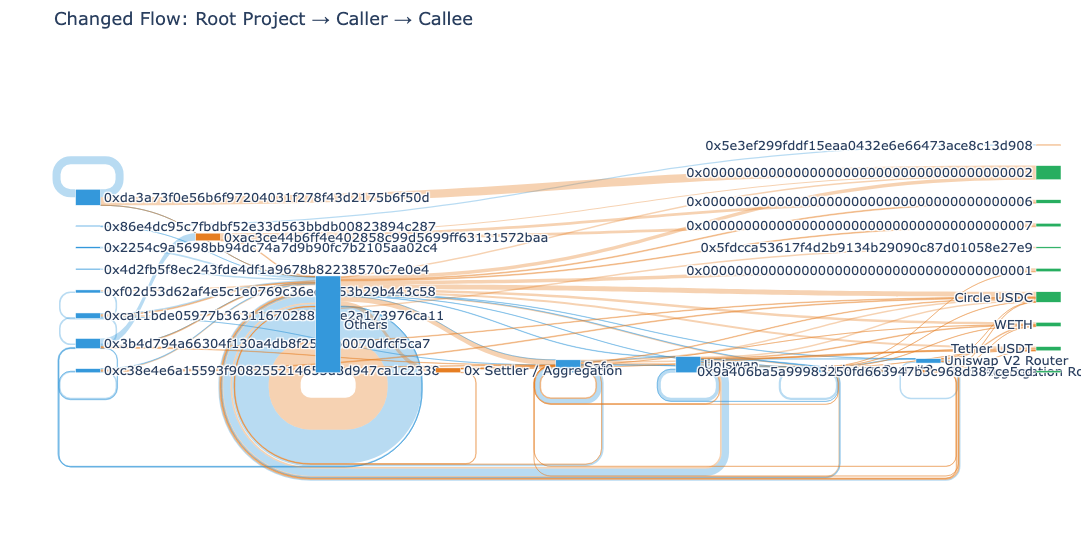

In [12]:
# Load changed non-root Sankey edges
ch_sankey = pd.read_csv(TABLES_DIR / 'changed_nonroot_sankey_edges.csv', nrows=5000)
print(f"Changed flow Sankey edges: {fmt_count(len(ch_sankey))}")
print(f"Total changed edges in sample: {fmt_count(ch_sankey['changed_edges'].sum())}")

fig = plot_sankey(
    ch_sankey,
    columns=['root_project', 'effective_caller_project', 'effective_callee_project'],
    title='Changed Flow: Root Project → Caller → Callee',
    value_col='changed_edges',
    min_flow=20,
    top_n=12,
    width=950, height=550,
)
fig.show()

Compare this to the failure Sankey above. The changed flow is much broader — many more
project-to-project interactions are affected, but most of these are behavioral changes
within still-succeeding transactions. The failure Sankey highlights the critical subset
where changes become catastrophic.

## 10. Non-Root Intermediaries — Change Amplifiers

Some contracts don't just *experience* behavioral changes — they **amplify** them. These
non-root intermediaries sit in the middle of the call graph, and when their behavior changes
under EIP-7904, the effect cascades to many downstream contracts.

The `intermediary_score` captures this amplification effect: how many distinct downstream
projects and transactions are affected by changes flowing through each intermediary.

Non-root intermediaries: 23.8K
Total changed edges through intermediaries: 2.05M


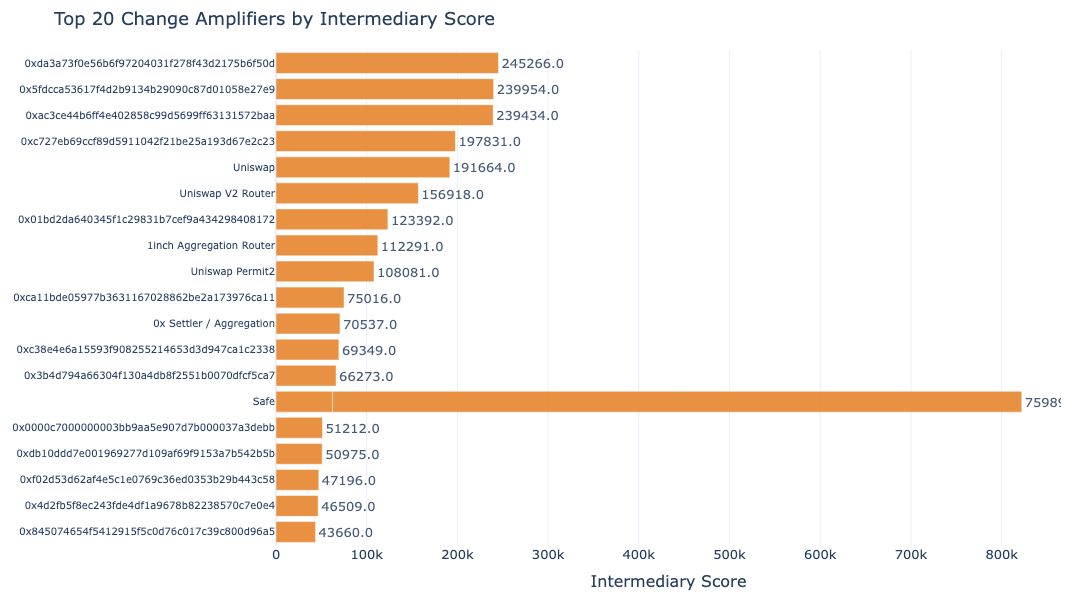


Top amplifier: Safe
  Intermediary score: 759894.0
  Changed edges: 87.4K
  Affects 23265 downstream projects across 1,165 txs


In [13]:
nr_intermediaries = read_table('changed_nonroot_intermediaries.csv')
print(f"Non-root intermediaries: {fmt_count(len(nr_intermediaries))}")
print(f"Total changed edges through intermediaries: {fmt_count(nr_intermediaries['changed_edges'].sum())}")

top_nr = nr_intermediaries.nlargest(20, 'intermediary_score').copy()
top_nr['label'] = top_nr['project'].fillna(top_nr['address'].str[:12] + '...')
top_nr = top_nr.sort_values('intermediary_score', ascending=True)

fig = go.Figure()
fig.add_trace(go.Bar(
    y=top_nr['label'].tolist(),
    x=top_nr['intermediary_score'].tolist(),
    orientation='h',
    marker_color=COLORS['increased'],
    opacity=0.85,
    text=[f"{v:.1f}" for v in top_nr['intermediary_score']],
    textposition='outside',
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Intermediary score: %{x:.1f}<br>'
        'Changed edges: %{customdata[0]:,}<br>'
        'Distinct downstream projects: %{customdata[1]}<br>'
        'Distinct txs: %{customdata[2]:,}<br>'
        'Success flip edges: %{customdata[3]:,}<extra></extra>'
    ),
    customdata=top_nr[['changed_edges', 'distinct_downstream_projects', 'distinct_txs', 'success_flip_edges']].values,
))
fig.update_layout(**plotly_layout(
    title_text='Top 20 Change Amplifiers by Intermediary Score',
    xaxis_title='Intermediary Score',
    height=600, width=900,
    margin=dict(l=250, r=20, t=50, b=40),
))
fig.update_yaxes(tickfont=dict(size=10))
fig.show()

top1 = top_nr.iloc[-1]
print(f"\nTop amplifier: {top1['label']}")
print(f"  Intermediary score: {top1['intermediary_score']:.1f}")
print(f"  Changed edges: {fmt_count(top1['changed_edges'])}")
print(f"  Affects {top1['distinct_downstream_projects']} downstream projects across {fmt_count(top1['distinct_txs'])} txs")

Change amplifiers are the contracts where a targeted fix (updating gas stipends, upgrading
the proxy implementation) would have the highest return on investment — a single contract
fix that resolves behavioral changes for many downstream projects.

## 11. First Divergence Points

When baseline and repriced executions first diverge in a transaction's call graph, what causes
the split? The `first_diff_reason` column in `tx_failure_paths` categorizes the trigger:

- **gas_delta**: The same call is made but uses different gas
- **success_flip**: A call that succeeded under baseline fails under the new schedule (or vice versa)
- **only_in_baseline**: A call exists in baseline but not in the repriced execution
- **only_in_schedule**: A call exists only in the repriced execution

Understanding *why* the first divergence happens helps prioritize which kind of changes to address.

In [14]:
# First divergence reason distribution
reason_counts = fp['first_diff_reason'].value_counts()
print("First divergence reasons:")
for reason, count in reason_counts.items():
    print(f"  {reason:<25} {fmt_count(count):>8} ({count/len(fp)*100:.1f}%)")

First divergence reasons:
  success_flip,gas_delta       50.0K (100.0%)


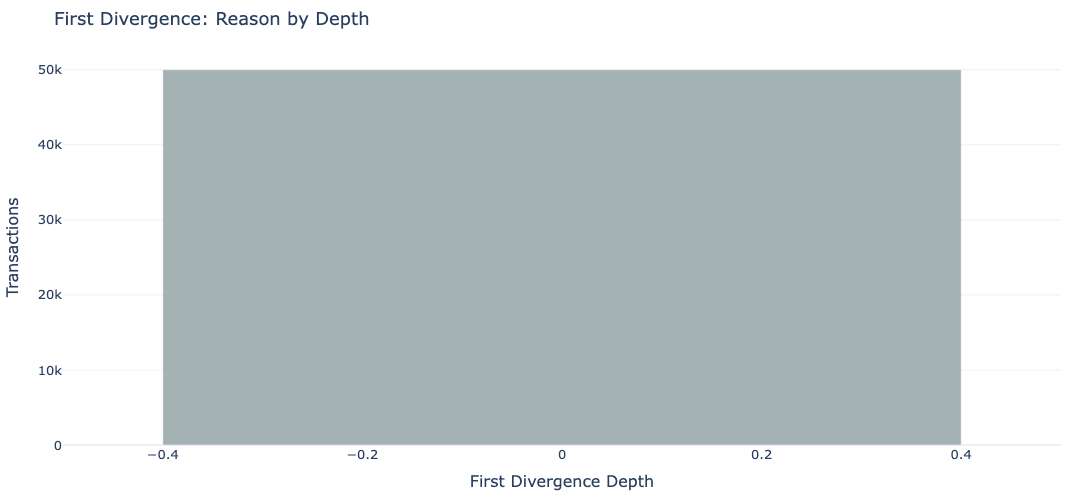


First divergence at depth <= 2: 50.0K (100.0%)
First divergence at depth > 2: 0 (0.0%)

Deep first-divergences are especially concerning — they indicate changes propagating
through multiple contract layers before the first visible effect.


In [15]:
# Stacked bar: first_diff_reason by first_diff_depth
reason_depth = fp.groupby(['first_diff_depth', 'first_diff_reason']).size().reset_index(name='count')

# Limit to reasonable depth range
max_depth = min(int(reason_depth['first_diff_depth'].quantile(0.95)), 15)
reason_depth = reason_depth[reason_depth['first_diff_depth'] <= max_depth]

reason_colors = {
    'gas_delta': COLORS['changed'],
    'success_flip': COLORS['status'],
    'only_in_baseline': COLORS['call_tree'],
    'only_in_schedule': COLORS['saved'],
}

fig = go.Figure()
for reason in reason_depth['first_diff_reason'].unique():
    subset = reason_depth[reason_depth['first_diff_reason'] == reason]
    fig.add_trace(go.Bar(
        x=subset['first_diff_depth'].tolist(),
        y=subset['count'].tolist(),
        name=reason,
        marker_color=reason_colors.get(reason, COLORS['neutral']),
        opacity=0.85,
    ))

fig.update_layout(
    barmode='stack',
    **plotly_layout(
        title_text='First Divergence: Reason by Depth',
        xaxis_title='First Divergence Depth',
        yaxis_title='Transactions',
        height=500, width=900,
    ),
)
fig.show()

shallow_div = fp[fp['first_diff_depth'] <= 2]
deep_div = fp[fp['first_diff_depth'] > 2]
print(f"\nFirst divergence at depth <= 2: {fmt_count(len(shallow_div))} ({len(shallow_div)/len(fp)*100:.1f}%)")
print(f"First divergence at depth > 2: {fmt_count(len(deep_div))} ({len(deep_div)/len(fp)*100:.1f}%)")
print(f"\nDeep first-divergences are especially concerning — they indicate changes propagating")
print(f"through multiple contract layers before the first visible effect.")

## 12. Key Findings

### Call tree changes are pervasive
A large fraction of divergent transactions have call tree changes — the internal structure of
contract interactions shifts even when the final transaction status doesn't flip. These silent
changes represent a broad but shallow impact.

### Failures concentrate at specific depths
Most failures occur at moderate call depths (2-4), corresponding to the common pattern of
EOA -> router/proxy -> target contract. Very deep failures (depth 5+) are rarer but involve
complex protocol interactions that are harder to remediate.

### A small number of motifs dominate
The top failure motifs account for the vast majority of breakage. A targeted fix for the top
5 project-to-project edges would resolve a disproportionate share of all failures.

### Chokepoints and amplifiers are actionable
The intermediary analysis identifies specific contracts where intervention would have outsized
impact. Upgradeable chokepoints are the highest-leverage targets for gas stipend fixes.
Change amplifiers are where a single contract update can resolve behavioral changes across
many downstream projects.

### First divergence is dominated by gas deltas
The most common reason for the first divergence is a gas delta — the same call is made but
costs more under EIP-7904. Success flips and missing calls are secondary effects that cascade
from the initial gas increase.

### The call graph structure matters
EIP-7904's impact is not just about individual opcodes getting more expensive. It's about
how gas costs propagate through interconnected contracts. The call graph acts as an amplifier:
a small per-opcode increase becomes a large per-transaction increase when multiplied across
nested call depths. Understanding this propagation is essential for predicting and mitigating
the real-world impact of gas repricing.